In [1]:
%pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 989.5/989.5 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.5/692.5 kB 38.0 MB/s eta 0:00:00


In [2]:
%pip install awkward_pandas

In [3]:
#imports

import numpy as np
import pandas as pd
import uproot
import awkward as ak
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [4]:
ROOT_FILE = "augmerged.root"

file = uproot.open(ROOT_FILE)

print(file.keys())

tree = file["ThreeG_NCS"]
print(tree.keys())


['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


In [5]:
branches = [

    "RunID",
    "EventID",

    "GammaIndex",
    'NGammas',

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head())

              RunID  EventID  GammaIndex  NGammas       X_mm       Y_mm  \
0  slurm_36283167_1       43           0        3  22.533781  45.725643   
1  slurm_36283167_1       43           1        3 -19.154974 -41.295967   
2  slurm_36283167_1       43           2        3  10.009033  22.802109   
3  slurm_36283167_1       56           0        3  15.187184  14.526692   
4  slurm_36283167_1       56           1        3   1.183054 -10.753192   

        Z_mm  EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  \
0  -6.039716         187.380234     187.380234             0.0     3.079860   
1  42.954437         471.598907     471.598907             0.0     3.079860   
2 -44.240387         363.018677     363.018677             0.0     3.079860   
3  46.622974         492.708618     492.708618             0.0    -0.369778   
4 -51.622868         304.623718     304.623718             0.0    -0.369778   

   AnnihilY_mm  AnnihilZ_mm  
0     6.565360    -6.969770  
1     6.565360

In [ ]:
# Check number of rows and events

print("Number of rows:", len(df))
print("Number of events:", df.groupby(["RunID", "EventID"]).ngroups)

print("\nNGammas values:")
print(df["NGammas"].value_counts())

print("\nGammaIndex values:")
print(df["GammaIndex"].value_counts())

In [6]:
# Get unique events
events = df[["RunID", "EventID"]].drop_duplicates()

# Select the first 15000 events
events_15000 = events.head(15000)

print("Number of events selected:", len(events_15000))

Number of events selected: 15000


In [7]:
df_15000 = df.merge(
    events_15000,
    on=["RunID", "EventID"],
    how="inner"
)

print("Number of rows:", len(df_15000))
print(
    "Number of events:",
    df_15000.groupby(["RunID", "EventID"]).ngroups
)

Number of rows: 45000
Number of events: 15000


Number of source positions: 15000


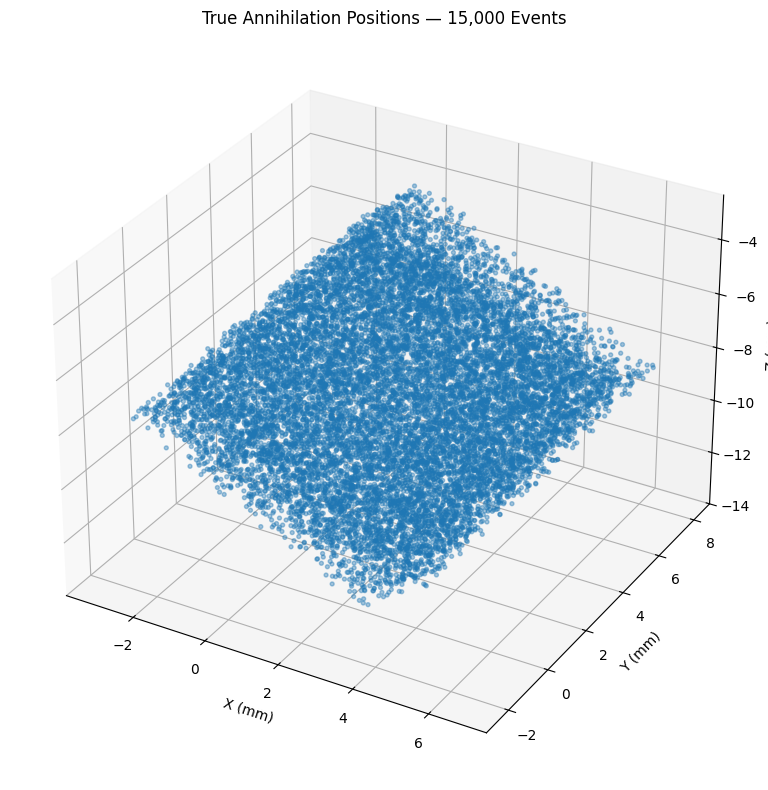

In [8]:
#source positions - 3d plot
source_positions = (
    df_15000
    .groupby(["RunID", "EventID"])
    [["AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm"]]
    .first()
    .values
)

print("Number of source positions:", len(source_positions))




fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    source_positions[:, 0],
    source_positions[:, 1],
    source_positions[:, 2],
    s=8,
    alpha=0.4
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")

ax.set_title("True Annihilation Positions — 15,000 Events")

plt.tight_layout()
plt.show()

In [9]:
#MLP targets input
X = []
y = []

# Loop through each event
for (run_id, event_id), event in df_15000.groupby(["RunID", "EventID"]):

    # Sort the gamma hits by GammaIndex
    event = event.sort_values("GammaIndex")

    # We need exactly 3 gamma hits
    if len(event) != 3:
        continue

    # 3 gamma positions


    positions = event[["X_mm", "Y_mm", "Z_mm"]].values

    # Turn:
    # [[X1,Y1,Z1],
    #  [X2,Y2,Z2],
    #  [X3,Y3,Z3]]
    #
    # into:
    # [X1,Y1,Z1,X2,Y2,Z2,X3,Y3,Z3]

    inputs = positions.flatten()


    # TARGET: annihilation position


    target = event[
        ["AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm"]
    ].iloc[0].values

    # Add to dataset
    X.append(inputs)
    y.append(target)


# Convert to numpy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)


# Check the result
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst event input:")
print(X[0])

print("\nFirst event target:")
print(y[0])

X shape: (15000, 9)
y shape: (15000, 3)

First event input:
[ 22.533781   45.725643   -6.0397162 -19.154974  -41.295967   42.954437
  10.009033   22.802109  -44.240387 ]

First event target:
[ 3.0798597  6.5653596 -6.96977  ]


In [10]:
# train val test split

from sklearn.model_selection import train_test_split

# First split:
# 80% training
# 20% temporary (validation + test)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# 3:2 VAL:TEST

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.33,
    random_state=42
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (12000, 9) (12000, 3)
Validation: (2010, 9) (2010, 3)
Test: (990, 9) (990, 3)


In [13]:
#scaling

from sklearn.preprocessing import StandardScaler

# Input scaler
input_scaler = StandardScaler()

X_train_scaled = input_scaler.fit_transform(X_train)
X_val_scaled = input_scaler.transform(X_val)
X_test_scaled = input_scaler.transform(X_test)


# Target scaler
target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(y_train)
y_val_scaled = target_scaler.transform(y_val)
y_test_scaled = target_scaler.transform(y_test)


print("Scaling complete")

Scaling complete


In [14]:
#building mlp

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(9,)),

    # One hidden layer
    tf.keras.layers.Dense(
        100,
        activation="relu"
    ),

    # Output: X, Y, Z
    tf.keras.layers.Dense(3)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,303 (5.09 KB)

 Trainable params: 1,303 (5.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#testing bets learning rate DO NOT RUN

learning_rates = [0.01, 0.001, 0.0001, 0.00001]

results = []

for lr in learning_rates:

    print("\n" + "=" * 50)
    print(f"Learning rate: {lr}")
    print("=" * 50)

    # Fresh model
    model_lr = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(9,)),
        tf.keras.layers.Dense(100, activation="relu"),
        tf.keras.layers.Dense(3)
    ])

    # Adam
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr
    )

    model_lr.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    # Train using training data
    history_lr = model_lr.fit(
        X_train_scaled,
        y_train_scaled,
        validation_data=(X_val_scaled, y_val_scaled),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    # ==========================================
    # VALIDATION PREDICTIONS
    # ==========================================

    val_pred_scaled = model_lr.predict(
        X_val_scaled,
        verbose=0
    )

    # Convert back to mm
    val_pred = target_scaler.inverse_transform(
        val_pred_scaled
    )

    # 3D distance error
    val_errors = np.sqrt(
        (val_pred[:, 0] - y_val[:, 0])**2 +
        (val_pred[:, 1] - y_val[:, 1])**2 +
        (val_pred[:, 2] - y_val[:, 2])**2
    )

    # Mean 3D error
    val_mean_error = np.mean(val_errors)

    # Coordinate MAE
    val_mae = np.mean(
        np.abs(val_pred - y_val)
    )

    # Save ONLY validation results
    results.append({
        "Learning Rate": lr,
        "Validation Mean Error (mm)": val_mean_error,
        "Validation MAE (mm)": val_mae
    })




results_df = pd.DataFrame(results)

print("\n")
print("LEARNING RATE COMPARISON")
print("=" * 65)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

In [15]:

# COMPILE MLP


optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.01
)

model.compile(
    optimizer=optimizer,
    loss="mae",
    metrics=["mae"]
)

In [16]:
#train

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.8268 - mae: 0.8268 - val_loss: 0.7970 - val_mae: 0.7970
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8101 - mae: 0.8101 - val_loss: 0.7932 - val_mae: 0.7932
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8075 - mae: 0.8075 - val_loss: 0.7939 - val_mae: 0.7939
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8052 - mae: 0.8052 - val_loss: 0.7875 - val_mae: 0.7875
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8021 - mae: 0.8021 - val_loss: 0.7948 - val_mae: 0.7948
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7994 - mae: 0.7994 - val_loss: 0.7860 - val_mae: 0.7860
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7967 - mae: 0.7967 - val_loss: 0.7884 - val_mae: 0.7884
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7949 - mae: 0.7949 - val_loss: 0.7830 - val_mae: 0.7830
Epoch 9/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

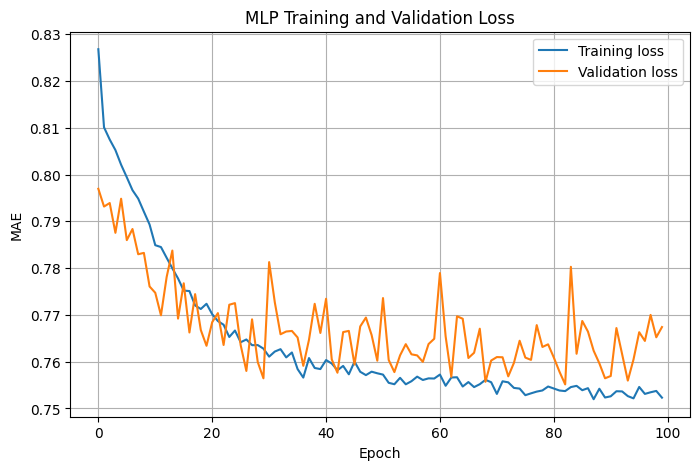

In [17]:
#trainign curve - loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
#predictions

y_pred_scaled = model.predict(X_test_scaled)

# Convert predictions back into mm
y_pred = target_scaler.inverse_transform(y_pred_scaled)

print("Predictions shape:", y_pred.shape)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predictions shape: (990, 3)


In [19]:
#3d erorr

errors = np.sqrt(
    (y_pred[:, 0] - y_test[:, 0])**2 +
    (y_pred[:, 1] - y_test[:, 1])**2 +
    (y_pred[:, 2] - y_test[:, 2])**2
)


print("MLP ANNIHILATION POSITION RECONSTRUCTION")


print(f"Mean error   : {np.mean(errors):.3f} mm")
print(f"Median error : {np.median(errors):.3f} mm")
print(f"Std error    : {np.std(errors):.3f} mm")
print(f"Maximum error: {np.max(errors):.3f} mm")

MLP ANNIHILATION POSITION RECONSTRUCTION
Mean error   : 3.315 mm
Median error : 3.156 mm
Std error    : 1.371 mm
Maximum error: 10.497 mm


In [20]:

# X/Y/Z MAE


x_mae = np.mean(np.abs(y_pred[:, 0] - y_test[:, 0]))
y_mae = np.mean(np.abs(y_pred[:, 1] - y_test[:, 1]))
z_mae = np.mean(np.abs(y_pred[:, 2] - y_test[:, 2]))

print(f"X MAE: {x_mae:.3f} mm")
print(f"Y MAE: {y_mae:.3f} mm")
print(f"Z MAE: {z_mae:.3f} mm")

X MAE: 1.610 mm
Y MAE: 1.943 mm
Z MAE: 1.470 mm


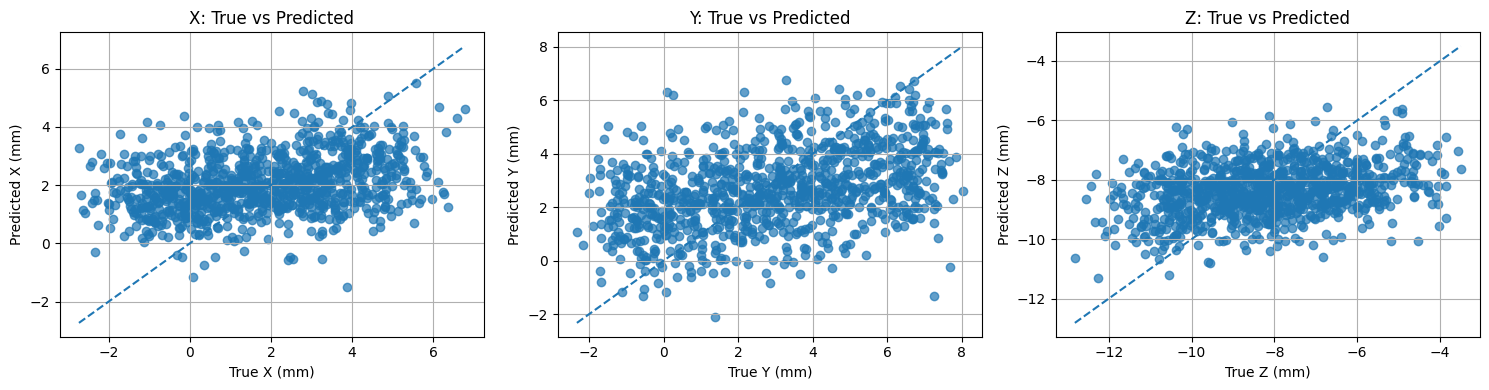

In [21]:

# TRUE VS PREDICTED X/Y/Z


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

coordinates = ["X", "Y", "Z"]

for i, coord in enumerate(coordinates):

    axes[i].scatter(
        y_test[:, i],
        y_pred[:, i],
        alpha=0.7
    )

    # Perfect prediction line
    minimum = min(
        y_test[:, i].min(),
        y_pred[:, i].min()
    )

    maximum = max(
        y_test[:, i].max(),
        y_pred[:, i].max()
    )

    axes[i].plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    axes[i].set_xlabel(f"True {coord} (mm)")
    axes[i].set_ylabel(f"Predicted {coord} (mm)")
    axes[i].set_title(f"{coord}: True vs Predicted")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

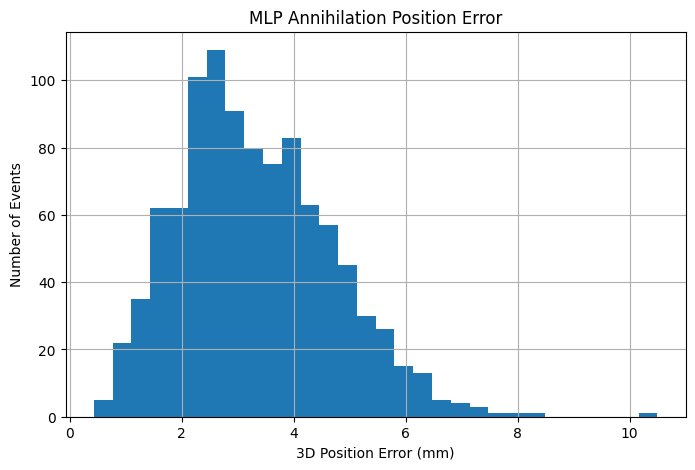

In [22]:
#RECONSTRUCTION ERROR DIST.

plt.figure(figsize=(8, 5))

plt.hist(errors, bins=30)

plt.xlabel("3D Position Error (mm)")
plt.ylabel("Number of Events")
plt.title("MLP Annihilation Position Error")

plt.grid(True)

plt.show()

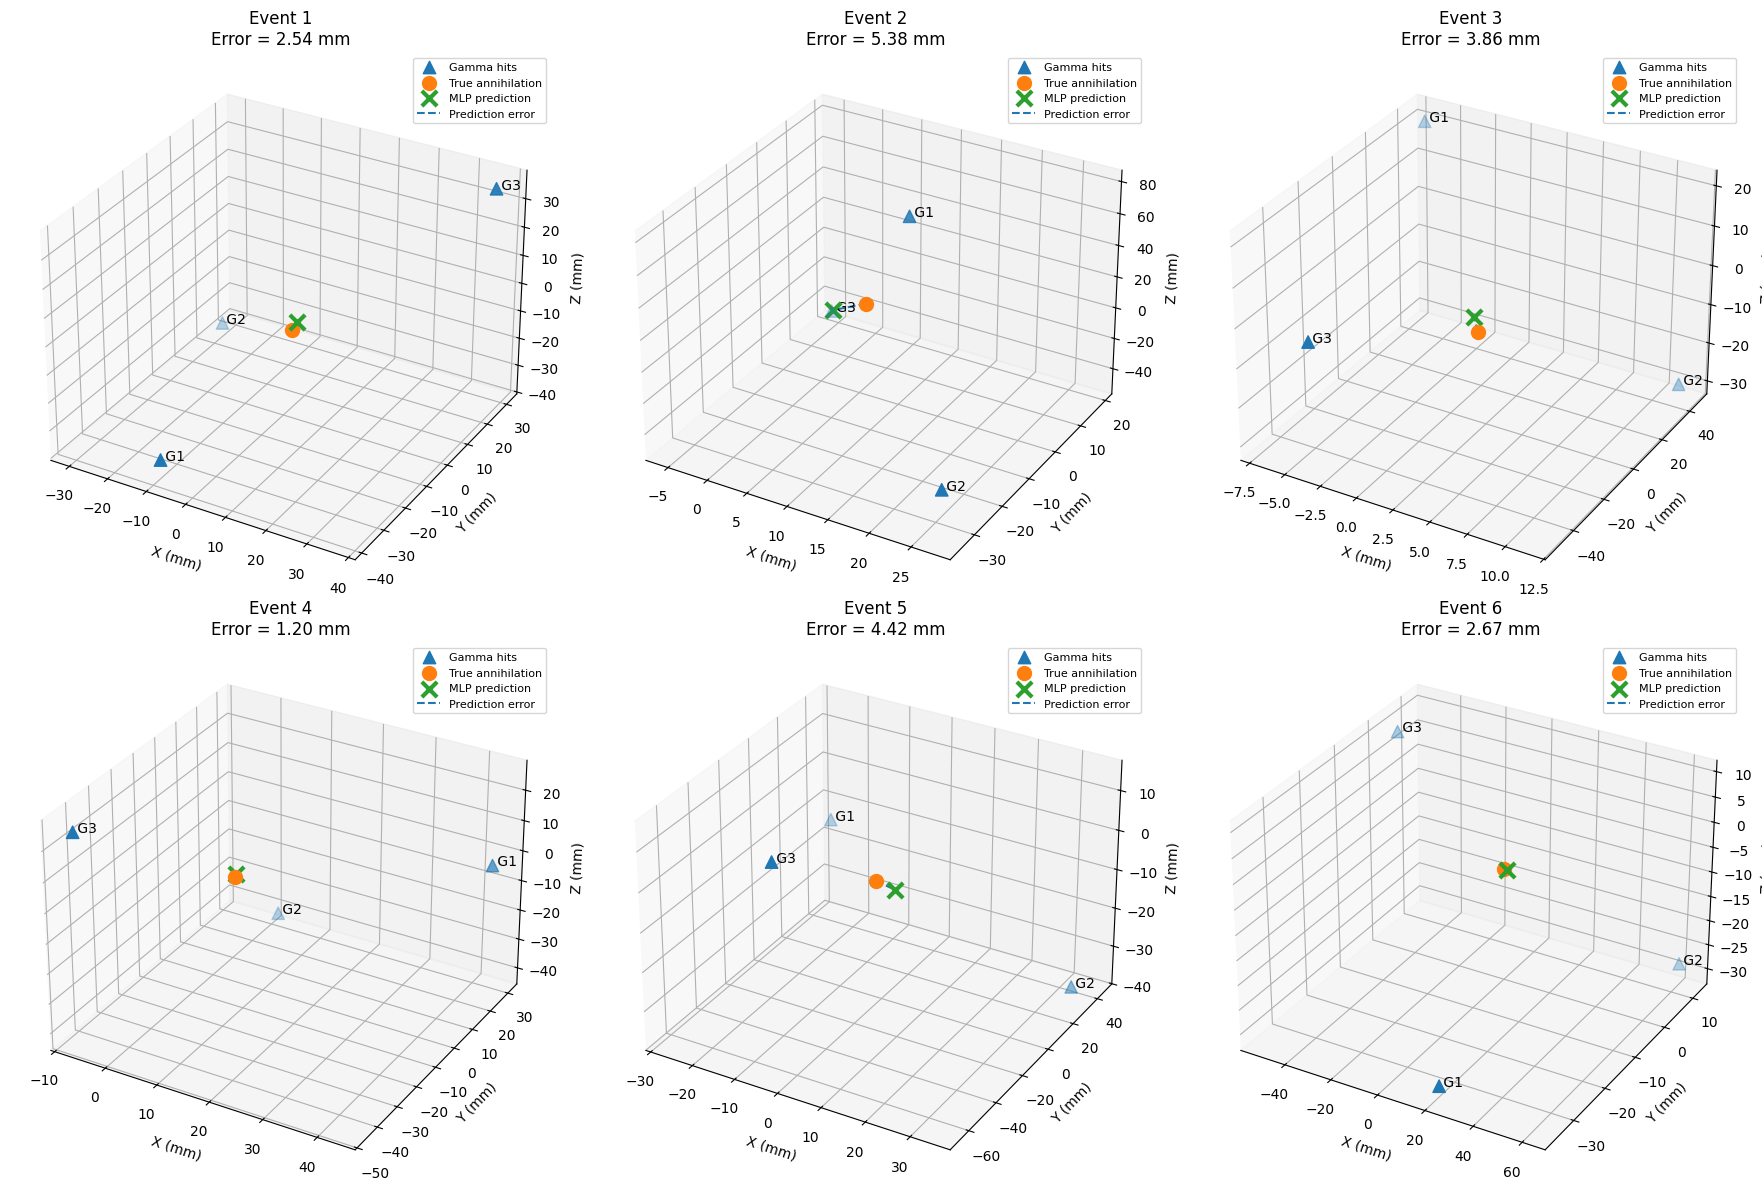

In [23]:
#3D ERROR

from mpl_toolkits.mplot3d import Axes3D

# Number of events to display
n_events = 6

fig = plt.figure(figsize=(18, 12))

for i in range(n_events):

    ax = fig.add_subplot(2, 3, i + 1, projection="3d")

    # --------------------------------------
    # Extract the 3 detector hit positions
    # --------------------------------------

    hits = X_test[i].reshape(3, 3)

    # --------------------------------------
    # True annihilation position
    # --------------------------------------

    true_pos = y_test[i]

    # --------------------------------------
    # MLP predicted annihilation position
    # --------------------------------------

    pred_pos = y_pred[i]

    # --------------------------------------
    # Plot detector hits
    # --------------------------------------

    ax.scatter(
        hits[:, 0],
        hits[:, 1],
        hits[:, 2],
        marker="^",
        s=80,
        label="Gamma hits"
    )

    # Label the three gamma hits
    for j in range(3):
        ax.text(
            hits[j, 0],
            hits[j, 1],
            hits[j, 2],
            f" G{j+1}"
        )

    # --------------------------------------
    # Plot TRUE annihilation
    # --------------------------------------

    ax.scatter(
        true_pos[0],
        true_pos[1],
        true_pos[2],
        marker="o",
        s=100,
        label="True annihilation"
    )

    # --------------------------------------
    # Plot PREDICTED annihilation
    # --------------------------------------

    ax.scatter(
        pred_pos[0],
        pred_pos[1],
        pred_pos[2],
        marker="x",
        s=120,
        linewidths=3,
        label="MLP prediction"
    )

    # --------------------------------------
    # Line between true and predicted
    # --------------------------------------

    ax.plot(
        [true_pos[0], pred_pos[0]],
        [true_pos[1], pred_pos[1]],
        [true_pos[2], pred_pos[2]],
        linestyle="--",
        label="Prediction error"
    )

    # --------------------------------------
    # Calculate error
    # --------------------------------------

    error = np.linalg.norm(
        pred_pos - true_pos
    )

    ax.set_title(
        f"Event {i+1}\n"
        f"Error = {error:.2f} mm"
    )

    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

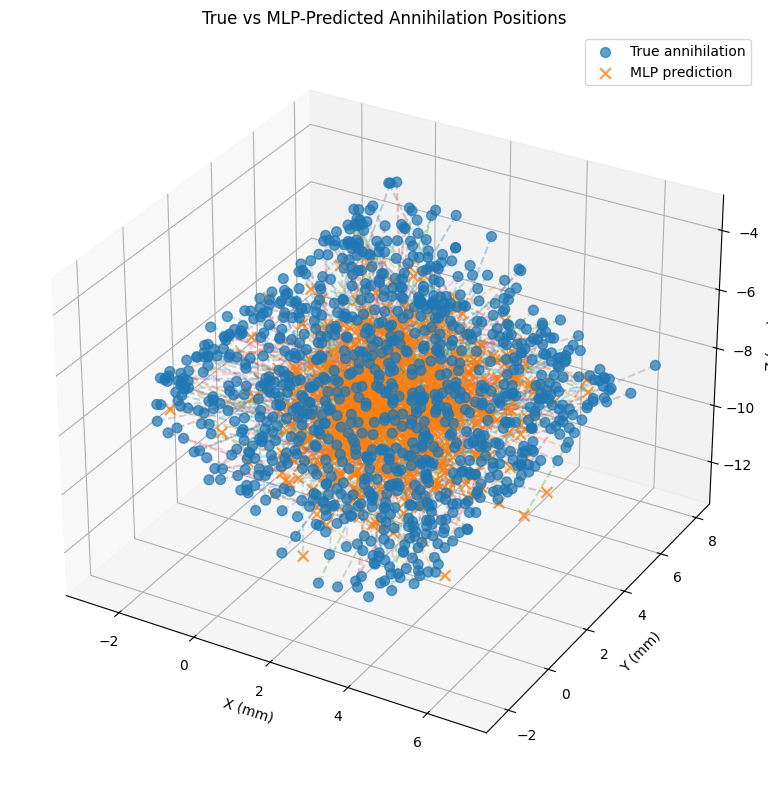

In [24]:
# TRUE VS PRED - 3D

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

# True annihilation positions
ax.scatter(
    y_test[:, 0],
    y_test[:, 1],
    y_test[:, 2],
    marker="o",
    s=50,
    alpha=0.7,
    label="True annihilation"
)

# MLP predictions
ax.scatter(
    y_pred[:, 0],
    y_pred[:, 1],
    y_pred[:, 2],
    marker="x",
    s=60,
    alpha=0.8,
    label="MLP prediction"
)

# Connect each true point to its prediction
for i in range(len(y_test)):

    ax.plot(
        [y_test[i, 0], y_pred[i, 0]],
        [y_test[i, 1], y_pred[i, 1]],
        [y_test[i, 2], y_pred[i, 2]],
        linestyle="--",
        alpha=0.3
    )

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")

ax.set_title(
    "True vs MLP-Predicted Annihilation Positions"
)

ax.legend()

plt.tight_layout()
plt.show()

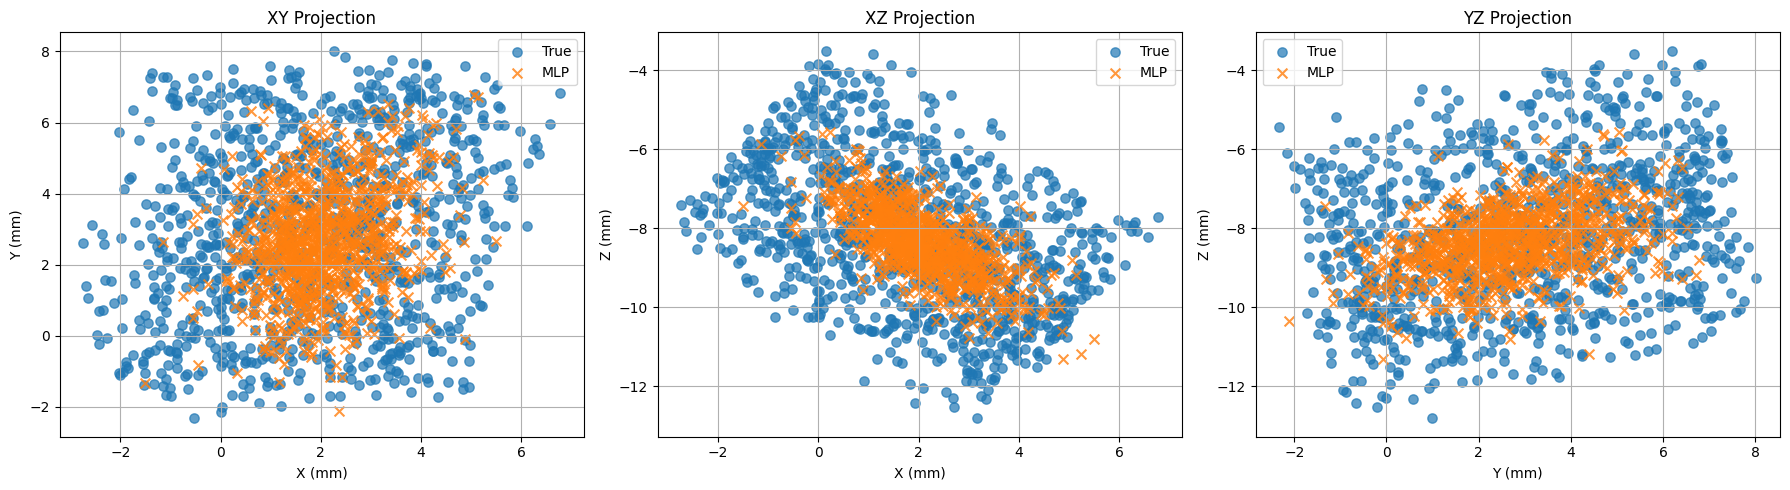

In [25]:
#2D PROJECTION

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

# ------------------------------------------
# XY
# ------------------------------------------

axes[0].scatter(
    y_test[:, 0],
    y_test[:, 1],
    marker="o",
    s=45,
    alpha=0.7,
    label="True"
)

axes[0].scatter(
    y_pred[:, 0],
    y_pred[:, 1],
    marker="x",
    s=50,
    alpha=0.8,
    label="MLP"
)

axes[0].set_xlabel("X (mm)")
axes[0].set_ylabel("Y (mm)")
axes[0].set_title("XY Projection")
axes[0].legend()
axes[0].grid(True)


# ------------------------------------------
# XZ
# ------------------------------------------

axes[1].scatter(
    y_test[:, 0],
    y_test[:, 2],
    marker="o",
    s=45,
    alpha=0.7,
    label="True"
)

axes[1].scatter(
    y_pred[:, 0],
    y_pred[:, 2],
    marker="x",
    s=50,
    alpha=0.8,
    label="MLP"
)

axes[1].set_xlabel("X (mm)")
axes[1].set_ylabel("Z (mm)")
axes[1].set_title("XZ Projection")
axes[1].legend()
axes[1].grid(True)


# ------------------------------------------
# YZ
# ------------------------------------------

axes[2].scatter(
    y_test[:, 1],
    y_test[:, 2],
    marker="o",
    s=45,
    alpha=0.7,
    label="True"
)

axes[2].scatter(
    y_pred[:, 1],
    y_pred[:, 2],
    marker="x",
    s=50,
    alpha=0.8,
    label="MLP"
)

axes[2].set_xlabel("Y (mm)")
axes[2].set_ylabel("Z (mm)")
axes[2].set_title("YZ Projection")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [26]:
#COMPARING TO BASELINE OF DEFAULTING TO MEAN

# Calculate the mean annihilation position
# using TRAINING data only
mean_position = np.mean(y_train, axis=0)

print("Mean annihilation position:")
print(f"X = {mean_position[0]:.3f} mm")
print(f"Y = {mean_position[1]:.3f} mm")
print(f"Z = {mean_position[2]:.3f} mm")


# Predict the same position for every test event
mean_predictions = np.tile(
    mean_position,
    (len(y_test), 1)
)


# ==========================================
# 3D ERROR FOR MEAN BASELINE
# ==========================================

mean_errors = np.sqrt(
    (mean_predictions[:, 0] - y_test[:, 0])**2 +
    (mean_predictions[:, 1] - y_test[:, 1])**2 +
    (mean_predictions[:, 2] - y_test[:, 2])**2
)

mean_3d_error = np.mean(mean_errors)
mean_median_error = np.median(mean_errors)

print("\n======================================")
print("MEAN POSITION BASELINE")
print("======================================")

print(f"Mean 3D error   : {mean_3d_error:.3f} mm")
print(f"Median 3D error : {mean_median_error:.3f} mm")
print(f"Maximum error   : {np.max(mean_errors):.3f} mm")


# ==========================================
# MLP VS MEAN BASELINE
# ==========================================

mlp_errors = np.sqrt(
    (y_pred[:, 0] - y_test[:, 0])**2 +
    (y_pred[:, 1] - y_test[:, 1])**2 +
    (y_pred[:, 2] - y_test[:, 2])**2
)

print("\n======================================")
print("MLP VS MEAN BASELINE")
print("======================================")

print(f"MLP mean 3D error  : {np.mean(mlp_errors):.3f} mm")
print(f"Mean baseline      : {np.mean(mean_errors):.3f} mm")

improvement = (
    (np.mean(mean_errors) - np.mean(mlp_errors))
    / np.mean(mean_errors)
    * 100
)

print(f"Improvement        : {improvement:.1f}%")


Mean annihilation position:
X = 1.825 mm
Y = 3.000 mm
Z = -8.142 mm

MEAN POSITION BASELINE
Mean 3D error   : 3.548 mm
Median 3D error : 3.669 mm
Maximum error   : 6.416 mm

MLP VS MEAN BASELINE
MLP mean 3D error  : 3.315 mm
Mean baseline      : 3.548 mm
Improvement        : 6.6%
